# World University Rankings Analysis

#### Introduction: In this project, I explored global university rankings using a dataset that includes over 2,200 institutions worldwide, combining information from three major sources: the Times Higher Education World University Ranking, the Shanghai Ranking, and the Center for World University Rankings. Each ranking uses different criteria, leading to notable differences in how universities are evaluated. To better understand these trends, I created four visualizations. First, I analyzed the top countries by their average university score. Then I focused on the top 10 universities in the United States to see how they compare nationally. I also used a boxplot to show the distribution of average scores across countries, highlighting both central tendencies and variation. Lastly, I created a scatterplot to explore the relationship between the number of publications and university score, using data from 2012–2015. With such a large number of institutions, these visualizations offer a meaningful look at global education trends, research output, and how different nations perform on the world stage.

Import Libraries

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as  sns

In [78]:
#Read in csv data
data = pd.read_csv('cwurData.csv')
df = pd.DataFrame(data)

### 1. Explore the Data

In [79]:
df.shape

(2200, 14)

#### 2200 Rows and 14 Columns

In [80]:
df.head(20)

,world_rank,institution,country,national_rank,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,score,year
0,1,Harvard University,USA,1,7,9,1,1,1,1,NaN,5,100.00,2012
1,2,Massachusetts Institute of Technology,USA,2,9,17,3,12,4,4,NaN,1,91.67,2012
2,3,Stanford University,USA,3,17,11,5,4,2,2,NaN,15,89.50,2012
3,4,University of Cambridge,United Kingdom,1,10,24,4,16,16,11,NaN,50,86.17,2012
4,5,California Institute of Technology,USA,4,2,29,7,37,22,22,NaN,18,85.21,2012
5,6,Princeton University,USA,5,8,14,2,53,33,26,NaN,101,82.50,2012
6,7,University of Oxford,United Kingdom,2,13,28,9,15,13,19,NaN,26,82.34,2012
7,8,Yale University,USA,6,14,31,12,14,6,15,NaN,66,79.14,2012
8,9,Columbia University,USA,7,23,21,10,13,12,14,NaN,5,78.86,2012
9,10,"University of California, Berkeley",USA,8,16,52,6,6,5,3,NaN,16,78.55,2012


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   world_rank            2200 non-null   int64  
 1   institution           2200 non-null   object 
 2   country               2200 non-null   object 
 3   national_rank         2200 non-null   int64  
 4   quality_of_education  2200 non-null   int64  
 5   alumni_employment     2200 non-null   int64  
 6   quality_of_faculty    2200 non-null   int64  
 7   publications          2200 non-null   int64  
 8   influence             2200 non-null   int64  
 9   citations             2200 non-null   int64  
 10  broad_impact          2000 non-null   float64
 11  patents               2200 non-null   int64  
 12  score                 2200 non-null   float64
 13  year                  2200 non-null   int64  
dtypes: float64(2), int64(10), object(2)
memory usage: 240.8+ KB


### 2. Clean and Transform Data

In [82]:
#Check for duplicate rows
duplicated = df[df.duplicated(subset = ['institution','year'])]
duplicated.head()

,world_rank,institution,country,national_rank,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,score,year


In [83]:
#Find and handle missing Values
df.isnull().sum()

world_rank                0
institution               0
country                   0
national_rank             0
quality_of_education      0
alumni_employment         0
quality_of_faculty        0
publications              0
influence                 0
citations                 0
broad_impact            200
patents                   0
score                     0
year                      0
dtype: int64

In [84]:
#Drop rows With missing broad_impact
df = df.dropna()

In [85]:
#Verify rows were dropped
df.isnull().sum()

world_rank              0
institution             0
country                 0
national_rank           0
quality_of_education    0
alumni_employment       0
quality_of_faculty      0
publications            0
influence               0
citations               0
broad_impact            0
patents                 0
score                   0
year                    0
dtype: int64

In [86]:
#Change 'year' data type to a Date
df['year'] = pd.to_datetime(df['year'], format='%Y')
df['year'].head()

200   2014-01-01
201   2014-01-01
202   2014-01-01
203   2014-01-01
204   2014-01-01
Name: year, dtype: datetime64[ns]

### 3. Visualize the Data

#### Top Countries by Average Score

C:\Users\zaque\AppData\Local\Temp\ipykernel_18060\2572932071.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_score_country, x='country', y='score', palette='deep')


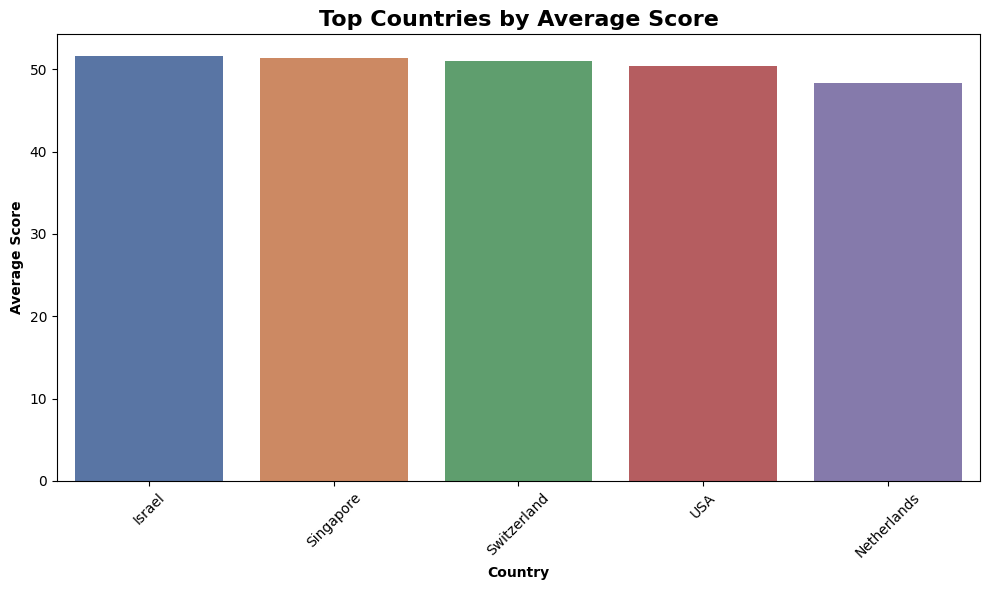

In [105]:
#Find Average Score by Country
avg_score_country = df.groupby('country')['score'].mean().sort_values(ascending=False).head(5).reset_index()

# Set plot size and style
plt.figure(figsize=(10,6))
sns.barplot(data=avg_score_country, x='country', y='score', palette='deep')  

plt.title('Top Countries by Average Score',fontsize='16', fontweight='bold')
plt.ylabel('Average Score',fontsize='10',fontweight='bold')
plt.xlabel('Country',fontsize='10',fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Top 10 U.S Schools by Average Score

In [88]:
# Filter for USA only
df_us = df[df['country'] == 'USA']

# Calculate average score by institution
avg_score_us = df_us.groupby('institution')['score'].mean().sort_values(ascending=False)

# Select top 10 (or 5)
top_us_schools = avg_score_us.head(5)




C:\Users\zaque\AppData\Local\Temp\ipykernel_18060\1577555959.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_us_schools.values, y=top_us_schools.index,palette='colorblind')


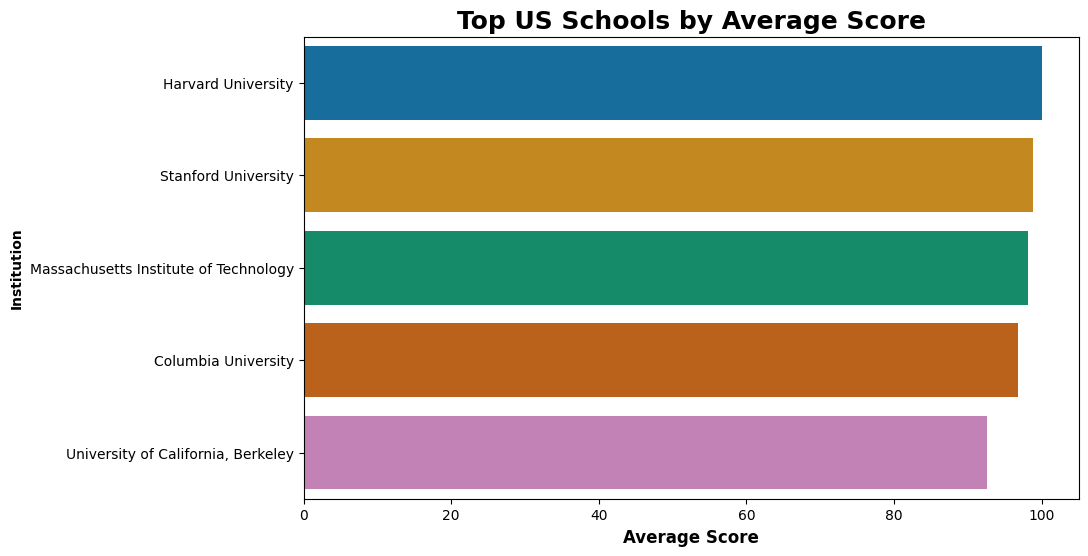

In [114]:
# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=top_us_schools.values, y=top_us_schools.index,palette='colorblind')
plt.title('Top US Schools by Average Score',fontsize= '18',fontweight='bold')
plt.xlabel('Average Score',fontsize='12',fontweight='bold')
plt.ylabel('Institution',fontsize='10',fontweight='bold')
plt.show()

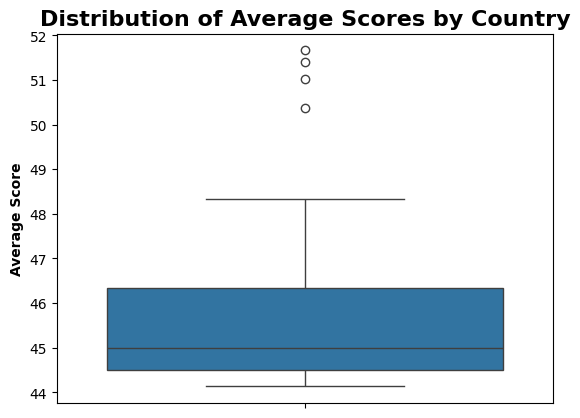

In [ ]:
#Find average Score by Country
df_country_avg = df.groupby('country')['score'].mean().reset_index()


#Plot boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(y=df_country_avg['score'])
plt.title('Distribution of Average Scores by Country',fontsize= '16',fontweight='bold')
plt.ylabel('Average Score',fontsize= '10',fontweight='bold')
plt.show()



#### The boxplot shows most countries have average scores between 44 and 47, with a few outliers reaching into the low 50s. This indicates that university scores are fairly clustered globally, with limited variation beyond the typical range.

### Relationship of Publications and Score

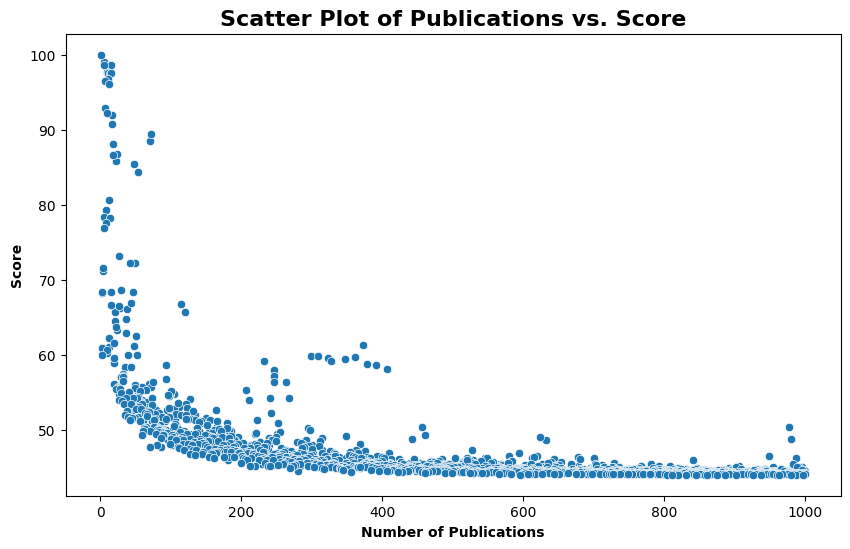

In [113]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='publications', y='score')
plt.title('Scatter Plot of Publications vs. Score',fontsize= '16',fontweight='bold')
plt.xlabel('Number of Publications',fontsize= '10',fontweight='bold')
plt.ylabel('Score',fontsize= '10',fontweight='bold')
plt.show()

In [92]:
print(df[['publications', 'score']].corr())


              publications     score
publications      1.000000 -0.526862
score            -0.526862  1.000000


#### From 2012 to 2015, the data shows a negative correlation between publication count and university score. Top-ranked schools like Harvard had fewer publications during this period, which may suggest they focus on Quality over Quantity. These institutions might produce research that takes longer to develop or publish in high-impact journals with more selective processes, resulting in fewer but more influential publications.